In [133]:
import pandas as pd
import numpy as np
import missingno as msno
from matplotlib import pyplot as plt
import re

In [134]:
filepath = '../data/sg-tech-jobs.csv'
df = pd.read_csv(filepath)
df

,bulletPoints/0,bulletPoints/1,bulletPoints/2,classifications/0/main,classifications/0/sub,company/description,company/id,company/logo,company/name,country,...,postDate,postDateDisplay,salary,scrapedAt,sourceUrl,title,workArrangement,workTypes/0,workTypes/1,workTypes/2
0,NaN,NaN,NaN,Information & Communication Technology,Help Desk & IT Support,PERSOL,60172709.0,https://bx-branding-gateway.cloud.seek.com.au/...,PERSOL,SG,...,2026-02-12T06:01:37Z,1h ago,"$3,000 – $3,500 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,IT Support Executive,NaN,Full time,NaN,NaN
1,"5 yrs of exp. in designing, implementing, main...",Dip/Deg in Information Technology/Computer Eng...,CCNA/CCNP/HCIA/HCIP cert. are highly desirable,Information & Communication Technology,Engineering - Network,SmartHire by SEEK,61571544.0,https://bx-branding-gateway.cloud.seek.com.au/...,Smarthire by SEEK,SG,...,2026-02-12T04:36:36Z,3h ago,"$6,000 – $9,000 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,Network Engineer / Senior Network Engineer,NaN,Full time,NaN,NaN
2,Diploma/Degree in IT/Computer Science or relat...,Experience in managing networks and understand...,"Proficiency in ERP systems, scripting, and SQL...",Information & Communication Technology,Help Desk & IT Support,SmartHire by SEEK,61571544.0,https://bx-branding-gateway.cloud.seek.com.au/...,Smarthire by SEEK,SG,...,2026-02-09T08:35:55Z,2d ago,"$2,800 – $3,500 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,Assistant IT Engineer (L1 Support // Semicondu...,NaN,Full time,NaN,NaN
3,"Comprehensive healthcare coverage (Up to $1,80...","Fostering (DEI), Diversity, Equity, and Inclus...",Employee Assistance Program,Information & Communication Technology,Help Desk & IT Support,Seagate International Headquarters Pte. Ltd.,60467326.0,https://bx-branding-gateway.cloud.seek.com.au/...,Seagate Technology,SG,...,2026-02-06T08:40:28Z,5d ago,"$4,200 – $5,200 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,IT Analyst (End User Services),NaN,Full time,NaN,NaN
4,NaN,NaN,NaN,Information & Communication Technology,Networks & Systems Administration,Caton Technology Asia Pte. Ltd.,63402287.0,NaN,Caton Technology Asia,SG,...,2026-02-12T03:33:51Z,4h ago,"$4,000 – $5,000 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,Technical Solution Engineer,NaN,Full time,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10075,NaN,NaN,NaN,Information & Communication Technology,Developers/Programmers,Neutron,61941084.0,NaN,Neutron,SG,...,2026-01-19T01:51:14Z,24d ago,NaN,2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,Senior Full Stack Engineer,NaN,Contract/Temp,Full time,NaN
10076,NaN,NaN,NaN,Information & Communication Technology,Product Management & Development,StarHub Ltd,60485608.0,NaN,StarHub,SG,...,2025-10-05T12:00:00Z,30d+ ago,NaN,2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,Salesforce/CloudSense Lead,NaN,Full time,NaN,NaN
10077,NaN,NaN,NaN,Information & Communication Technology,Engineering - Software,CAPGEMINI SINGAPORE PTE. LTD.,60506714.0,NaN,Capgemini,SG,...,2025-05-06T08:00:09Z,30d+ ago,NaN,2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,Gen AI Lead,NaN,Full time,NaN,NaN
10078,NaN,NaN,NaN,Information & Communication Technology,Networks & Systems Administration,Good Job Creations (Singapore) Pte Ltd,60252422.0,https://bx-branding-gateway.cloud.seek.com.au/...,Good Job Creations,SG,...,2026-02-06T12:15:01Z,5d ago,"$5,000 - $6,000",2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,"(Japanese Speaking) Infrastructure Engineer, I...",NaN,Full time,NaN,NaN


In [135]:
df.duplicated().sum()

np.int64(0)

In [136]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   bulletPoints/0          1828 non-null   str    
 1   bulletPoints/1          1777 non-null   str    
 2   bulletPoints/2          1613 non-null   str    
 3   classifications/0/main  10080 non-null  str    
 4   classifications/0/sub   10080 non-null  str    
 5   company/description     10080 non-null  str    
 6   company/id              9969 non-null   float64
 7   company/logo            5797 non-null   str    
 8   company/name            8184 non-null   str    
 9   country                 10080 non-null  str    
 10  description             10068 non-null  str    
 11  isExpiringSoon          3513 non-null   object 
 12  jobId                   10080 non-null  int64  
 13  jobSearchUrl            10080 non-null  str    
 14  location                10080 non-null  str    
 

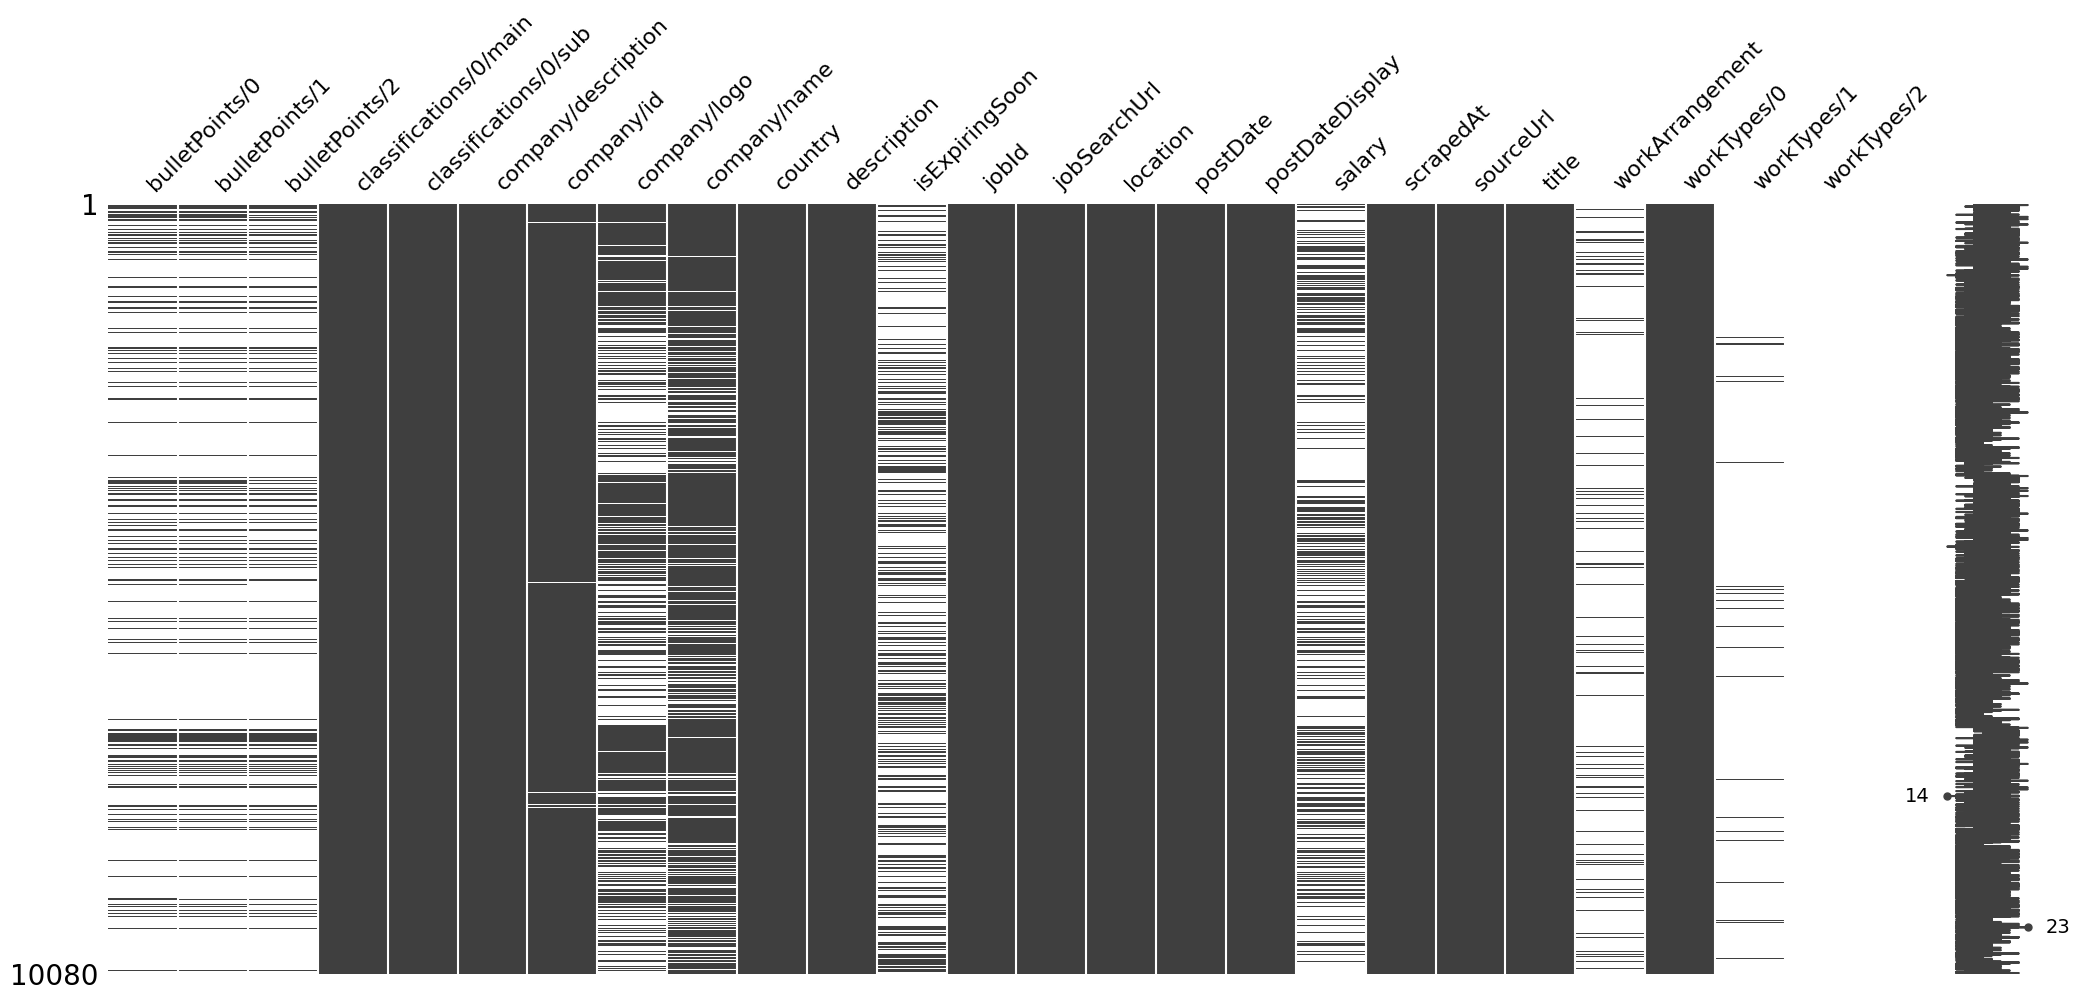

In [137]:
msno.matrix(df)
plt.show()

In [138]:
df['salary'].str.contains('$|SGD').value_counts()

salary
False    6470
True     3610
Name: count, dtype: int64

In [139]:
df_with_salary = df[df['salary'].notna()]
df_with_salary

,bulletPoints/0,bulletPoints/1,bulletPoints/2,classifications/0/main,classifications/0/sub,company/description,company/id,company/logo,company/name,country,...,postDate,postDateDisplay,salary,scrapedAt,sourceUrl,title,workArrangement,workTypes/0,workTypes/1,workTypes/2
0,NaN,NaN,NaN,Information & Communication Technology,Help Desk & IT Support,PERSOL,60172709.0,https://bx-branding-gateway.cloud.seek.com.au/...,PERSOL,SG,...,2026-02-12T06:01:37Z,1h ago,"$3,000 – $3,500 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,IT Support Executive,NaN,Full time,NaN,NaN
1,"5 yrs of exp. in designing, implementing, main...",Dip/Deg in Information Technology/Computer Eng...,CCNA/CCNP/HCIA/HCIP cert. are highly desirable,Information & Communication Technology,Engineering - Network,SmartHire by SEEK,61571544.0,https://bx-branding-gateway.cloud.seek.com.au/...,Smarthire by SEEK,SG,...,2026-02-12T04:36:36Z,3h ago,"$6,000 – $9,000 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,Network Engineer / Senior Network Engineer,NaN,Full time,NaN,NaN
2,Diploma/Degree in IT/Computer Science or relat...,Experience in managing networks and understand...,"Proficiency in ERP systems, scripting, and SQL...",Information & Communication Technology,Help Desk & IT Support,SmartHire by SEEK,61571544.0,https://bx-branding-gateway.cloud.seek.com.au/...,Smarthire by SEEK,SG,...,2026-02-09T08:35:55Z,2d ago,"$2,800 – $3,500 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,Assistant IT Engineer (L1 Support // Semicondu...,NaN,Full time,NaN,NaN
3,"Comprehensive healthcare coverage (Up to $1,80...","Fostering (DEI), Diversity, Equity, and Inclus...",Employee Assistance Program,Information & Communication Technology,Help Desk & IT Support,Seagate International Headquarters Pte. Ltd.,60467326.0,https://bx-branding-gateway.cloud.seek.com.au/...,Seagate Technology,SG,...,2026-02-06T08:40:28Z,5d ago,"$4,200 – $5,200 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,IT Analyst (End User Services),NaN,Full time,NaN,NaN
4,NaN,NaN,NaN,Information & Communication Technology,Networks & Systems Administration,Caton Technology Asia Pte. Ltd.,63402287.0,NaN,Caton Technology Asia,SG,...,2026-02-12T03:33:51Z,4h ago,"$4,000 – $5,000 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,Technical Solution Engineer,NaN,Full time,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10063,Room and opportunities to grow – on your own a...,"Resources to support your growth, productivity...",Flexibility to get your best work,Information & Communication Technology,Engineering - Software,Google,63281251.0,https://bx-branding-gateway.cloud.seek.com.au/...,Google,SG,...,2026-01-22T15:04:54Z,20d ago,World Class Benefits,2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,"Software Engineer, Cloud GPU, PhD, Early Caree...",NaN,Full time,NaN,NaN
10066,Room and opportunities to grow – on your own a...,"Resources to support your growth, productivity...",Flexibility to get your best work,Information & Communication Technology,Engineering - Software,Google,63281251.0,https://bx-branding-gateway.cloud.seek.com.au/...,Google,SG,...,2026-02-09T21:03:26Z,2d ago,World Class Benefits,2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,"Software Engineering Manager, Cloud ML Compute...",NaN,Full time,NaN,NaN
10067,Room and opportunities to grow – on your own a...,"Resources to support your growth, productivity...",Flexibility to get your best work,Information & Communication Technology,Engineering - Software,Google,63281251.0,https://bx-branding-gateway.cloud.seek.com.au/...,Google,SG,...,2026-01-22T15:07:24Z,20d ago,World Class Benefits,2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,"Staff Data Engineer, GenAI Application

In [140]:
df_with_salary[df_with_salary['salary'] == 'NaN']

,bulletPoints/0,bulletPoints/1,bulletPoints/2,classifications/0/main,classifications/0/sub,company/description,company/id,company/logo,company/name,country,...,postDate,postDateDisplay,salary,scrapedAt,sourceUrl,title,workArrangement,workTypes/0,workTypes/1,workTypes/2


In [141]:
df_with_salary[~df_with_salary['salary'].str.contains(r'\d')]

,bulletPoints/0,bulletPoints/1,bulletPoints/2,classifications/0/main,classifications/0/sub,company/description,company/id,company/logo,company/name,country,...,postDate,postDateDisplay,salary,scrapedAt,sourceUrl,title,workArrangement,workTypes/0,workTypes/1,workTypes/2
83,Diverse opportunities across multiple business...,Develop and realise your ideas and contributions.,Immerse in a culture of excellence and innovat...,Information & Communication Technology,Engineering - Software,Changi Airport Group (Singapore) Pte. Ltd.,60501603.0,https://bx-branding-gateway.cloud.seek.com.au/...,Changi Airport Group,SG,...,2026-02-12T00:15:33Z,7h ago,Competitive,2026-02-12T07:39:12.016Z,https://sg.jobstreet.com/jobs-in-information-c...,"Assistant Manager / Manager, Building Systems",NaN,Full time,NaN,NaN
325,Diverse opportunities across multiple business...,Develop and realise your ideas and contributions.,Immerse in a culture of excellence and innovat...,Information & Communication Technology,Engineering - Network,Changi Airport Group (Singapore) Pte. Ltd.,60501603.0,https://bx-branding-gateway.cloud.seek.com.au/...,Changi Airport Group,SG,...,2026-01-17T07:25:09Z,26d ago,Competitive,2026-02-12T07:40:11.417Z,https://sg.jobstreet.com/jobs-in-information-c...,High-Level Control Manager (Baggage Handling S...,NaN,Full time,NaN,NaN
392,NaN,NaN,NaN,Information & Communication Technology,Help Desk & IT Support,ScienTec Consulting Pte Ltd,60503573.0,https://bx-branding-gateway.cloud.seek.com.au/...,ScienTec Consulting,SG,...,2026-02-11T11:59:05Z,19h ago,Competitive,2026-02-12T07:40:25.920Z,https://sg.jobstreet.com/jobs-in-information-c...,App Support Engineer L1,NaN,Contract/Temp,NaN,NaN
579,Room and opportunities to grow – on your own a...,"Resources to support your growth, productivity...",Flexibility to get your best work,Information & Communication Technology,Product Management & Development,Google,63281251.0,https://bx-branding-gateway.cloud.seek.com.au/...,Google,SG,...,2026-02-10T17:15:53Z,1d ago,World Class Benefits,2026-02-12T07:41:13.723Z,https://sg.jobstreet.com/jobs-in-information-c...,"Technical Program Manager, Applied AI",NaN,Full time,NaN,NaN
583,Cutting-Edge Tech Exposure,MNC IT Company,Collaborative environment,Information & Communication Technology,Business/Systems Analysts,Peoplebank Singapore Pte Ltd,60175746.0,https://bx-branding-gateway.cloud.seek.com.au/...,Peoplebank,SG,...,2026-02-04T01:00:08Z,8d ago,Competitive,2026-02-12T07:41:13.723Z,https://sg.jobstreet.com/jobs-in-information-c...,Systems & Data Analyst (KPI Reporting & Busine...,NaN,Contract/Temp,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9934,Room and opportunities to grow – on your own a...,"Resources to support your growth, productivity...",Flexibility to get your best work,Information & Communication Technology,Consultants,Google,63281251.0,https://bx-branding-gateway.cloud.seek.com.au/...,Google,SG,...,2026-02-04T10:26:19Z,7d ago,World Class Benefits,2026-02-12T08:23:12.816Z,https://sg.jobstreet.com/jobs-in-information-c...,"Senior Integration Engineer, Professional Serv...",NaN,Full time,NaN,NaN
9936,NaN,NaN,NaN,Information & Communication Technology,Business/Systems Analysts,EtonHouse International Holdings Pte Ltd,60488122.0,https://bx-branding-gateway.cloud.seek.com.au/...,EtonHouse International Education Group,SG,...,2026-01-20T07:02:43Z,23d ago,-,2026-02-12T08:23:12.816Z,https://sg.jobstreet.com/jobs-in-information-c...,usiness Intelligence (BI) Engineer - 1 year co...,NaN,Contract/Temp,NaN,NaN
10063,Room and opportunities to grow – on your own a...,"Resources to support your growth, productivity...",Flexibility to get your best work,Information & Communication Technology,Engineering - Software,Google,63281251.0,https://bx-branding-gateway.cloud.seek.com.au/...,Google,SG,...,2026-01-22T15:04:54Z,20d ago,World Class Benefits,2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,"So

In [142]:
df_with_salary[~df_with_salary['salary'].str.contains(r'\d')]['salary'].value_counts()

salary
World Class Benefits                                158
Competitive                                          27
-                                                     9
Aws,Bonus                                             6
Salary commensurate with experience                   3
Market Aligned                                        3
Add expected salary to your profile for insights      3
As per Industry norms                                 3
Name: count, dtype: int64

In [143]:
df_with_salary = df_with_salary[df_with_salary['salary'].str.contains(r'\d')]
df_with_salary

,bulletPoints/0,bulletPoints/1,bulletPoints/2,classifications/0/main,classifications/0/sub,company/description,company/id,company/logo,company/name,country,...,postDate,postDateDisplay,salary,scrapedAt,sourceUrl,title,workArrangement,workTypes/0,workTypes/1,workTypes/2
0,NaN,NaN,NaN,Information & Communication Technology,Help Desk & IT Support,PERSOL,60172709.0,https://bx-branding-gateway.cloud.seek.com.au/...,PERSOL,SG,...,2026-02-12T06:01:37Z,1h ago,"$3,000 – $3,500 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,IT Support Executive,NaN,Full time,NaN,NaN
1,"5 yrs of exp. in designing, implementing, main...",Dip/Deg in Information Technology/Computer Eng...,CCNA/CCNP/HCIA/HCIP cert. are highly desirable,Information & Communication Technology,Engineering - Network,SmartHire by SEEK,61571544.0,https://bx-branding-gateway.cloud.seek.com.au/...,Smarthire by SEEK,SG,...,2026-02-12T04:36:36Z,3h ago,"$6,000 – $9,000 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,Network Engineer / Senior Network Engineer,NaN,Full time,NaN,NaN
2,Diploma/Degree in IT/Computer Science or relat...,Experience in managing networks and understand...,"Proficiency in ERP systems, scripting, and SQL...",Information & Communication Technology,Help Desk & IT Support,SmartHire by SEEK,61571544.0,https://bx-branding-gateway.cloud.seek.com.au/...,Smarthire by SEEK,SG,...,2026-02-09T08:35:55Z,2d ago,"$2,800 – $3,500 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,Assistant IT Engineer (L1 Support // Semicondu...,NaN,Full time,NaN,NaN
3,"Comprehensive healthcare coverage (Up to $1,80...","Fostering (DEI), Diversity, Equity, and Inclus...",Employee Assistance Program,Information & Communication Technology,Help Desk & IT Support,Seagate International Headquarters Pte. Ltd.,60467326.0,https://bx-branding-gateway.cloud.seek.com.au/...,Seagate Technology,SG,...,2026-02-06T08:40:28Z,5d ago,"$4,200 – $5,200 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,IT Analyst (End User Services),NaN,Full time,NaN,NaN
4,NaN,NaN,NaN,Information & Communication Technology,Networks & Systems Administration,Caton Technology Asia Pte. Ltd.,63402287.0,NaN,Caton Technology Asia,SG,...,2026-02-12T03:33:51Z,4h ago,"$4,000 – $5,000 per month",2026-02-12T07:38:56.418Z,https://sg.jobstreet.com/jobs-in-information-c...,Technical Solution Engineer,NaN,Full time,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10055,NaN,NaN,NaN,Information & Communication Technology,Engineering - Software,Private Advertiser,NaN,NaN,Private Advertiser,SG,...,2026-01-29T07:35:19Z,14d ago,"$8,000 – $12,000 per month",2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,DH Solution Consulting Engineer (FT Handler),NaN,Full time,NaN,NaN
10056,NaN,NaN,NaN,Information & Communication Technology,Developers/Programmers,Certis Group,60178895.0,https://bx-branding-gateway.cloud.seek.com.au/...,Certis,SG,...,2026-01-30T01:59:22Z,13d ago,"$4,000 – $6,000 per month",2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,RPA Developer,NaN,Full time,NaN,NaN
10062,NaN,NaN,NaN,Information & Communication Technology,Sales - Pre & Post,APBA TG Human Resource Pte Ltd,60526916.0,https://bx-branding-gateway.cloud.seek.com.au/...,TG Group Pte Ltd,SG,...,2026-01-27T07:46:49Z,16d ago,"$4,000 – $6,000 per month",2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,Sales Engineer (GPU Solutions & Hardware),NaN,Full time,NaN,NaN
10070,NaN,NaN,NaN,Information & Communication Technology,Database Development & Administration,RecruitFirst Pte. Ltd,60173576.0,https://bx-branding-gateway.cloud.seek.com.au/...,RecruitFirst,SG,...,2026-01-13T01:10:15Z,30d+ ago,"$6,000 per month",2026-02-12T08:23:49.116Z,https://sg.jobstreet.com/jobs-in-information-c...,"Data Engineer *SQL - UP $6000, Ubi",NaN

In [144]:
df_with_salary[df_with_salary['salary'].str.lower().str.contains('hour')]

,bulletPoints/0,bulletPoints/1,bulletPoints/2,classifications/0/main,classifications/0/sub,company/description,company/id,company/logo,company/name,country,...,postDate,postDateDisplay,salary,scrapedAt,sourceUrl,title,workArrangement,workTypes/0,workTypes/1,workTypes/2
207,Free breakfast and beverages from reputably br...,In-house gym and fitness corner,Collaborative & Supportive Team Culture,Information & Communication Technology,Help Desk & IT Support,Lumens Pte Ltd,60238347.0,https://bx-branding-gateway.cloud.seek.com.au/...,Lumens Group,SG,...,2026-01-29T03:47:50Z,14d ago,$12 per hour,2026-02-12T07:39:42.220Z,https://sg.jobstreet.com/jobs-in-information-c...,Operations Support Specialist (6 months contract),NaN,Contract/Temp,NaN,NaN
478,Working with innovative and collaborative team...,"Salary up to S$8,500 + AWS",Hybrid work arrangements,Information & Communication Technology,Engineering - Software,ScienTec Consulting Pte Ltd,60503573.0,https://bx-branding-gateway.cloud.seek.com.au/...,ScienTec Consulting,SG,...,2026-02-09T08:29:05Z,2d ago,SGD 3500 - 8500 per hour,2026-02-12T07:40:41.120Z,https://sg.jobstreet.com/jobs-in-information-c...,Software Quality Engineer,Hybrid,Full time,NaN,NaN
550,NaN,NaN,NaN,Information & Communication Technology,Help Desk & IT Support,Kingsforce Management Services Pte Ltd,60307328.0,https://bx-branding-gateway.cloud.seek.com.au/...,Kingsforce Management Services Pte Ltd,SG,...,2026-02-02T03:24:08Z,10d ago,$8.50 – $10 per hour,2026-02-12T07:41:06.318Z,https://sg.jobstreet.com/jobs-in-information-c...,IT Part-Time Assistant (Open to Fresh Grads),NaN,Part time,NaN,NaN
3248,5-day Work Week (Monday to Friday),Public Transport Accessible,NaN,Information & Communication Technology,Business/Systems Analysts,Elitez Pte Ltd,60540498.0,https://bx-branding-gateway.cloud.seek.com.au/...,Elitez Group,SG,...,2026-01-21T07:13:13Z,22d ago,$13 – $20 per hour,2026-02-12T07:52:58.319Z,https://sg.jobstreet.com/jobs-in-information-c...,Survey and Data Analyst - 1 Year Contract,NaN,Contract/Temp,NaN,NaN
3764,Free breakfast and beverages from reputably br...,In-house gym and fitness corner,Collaborative & Supportive Team Culture,Information & Communication Technology,Help Desk & IT Support,Lumens Pte Ltd,60238347.0,https://bx-branding-gateway.cloud.seek.com.au/...,Lumens Group,SG,...,2026-01-29T03:47:50Z,14d ago,$12 per hour,2026-02-12T07:56:06.815Z,https://sg.jobstreet.com/jobs-in-information-c...,Operations Support Specialist (6 months contract),NaN,Contract/Temp,NaN,NaN
4027,Working with innovative and collaborative team...,"Salary up to S$8,500 + AWS",Hybrid work arrangements,Information & Communication Technology,Engineering - Software,ScienTec Consulting Pte Ltd,60503573.0,https://bx-branding-gateway.cloud.seek.com.au/...,ScienTec Consulting,SG,...,2026-02-09T08:29:05Z,2d ago,SGD 3500 - 8500 per hour,2026-02-12T07:57:08.517Z,https://sg.jobstreet.com/jobs-in-information-c...,Software Quality Engineer,Hybrid,Full time,NaN,NaN
4097,NaN,NaN,NaN,Information & Communication Technology,Help Desk & IT Support,Kingsforce Management Services Pte Ltd,60307328.0,https://bx-branding-gateway.cloud.seek.com.au/...,Kingsforce Management Services Pte Ltd,SG,...,2026-02-02T03:24:08Z,10d ago,$8.50 – $10 per hour,2026-02-12T07:57:30.326Z,https://sg.jobstreet.com/jobs-in-information-c...,IT Part-Time Assistant (Open to Fresh Grads),NaN,Part time,NaN,NaN
6796,5-day Work Week (Monday to Friday),Public Transport Accessible,NaN,Information & Communication Technology,Business/Systems Analysts,Elitez Pte Ltd,60540498.0,https://bx-branding-gateway.cloud.seek.com.au/...,Elitez Group,SG,...,2026-01-21T07:13:13Z,22d ago,$13 – $20 per hour,2026-02-12T08:08:54.725Z,https://sg.jobstreet.com/jobs-in-information-c...,Survey and Data Analyst - 1 Year Contract,NaN,Contract/Temp,NaN,NaN
7056,Free breakfast and beverages from reputably br...,In-house gym and fitness corner,Collaborative & Supportive Team Culture,Information & Communication Technolo

Convert to monthly salary (40 hrs per week and 4 weeks per month) if hourly salary is found (assuming hourly rate is less than SGD 50).

In [145]:
def extract_salary(salary_string):
    if pd.isna(salary_string):
        return None
    
    s = str(salary_string).replace('$', '').replace(',', '').lower()
    nums = re.findall(r'\d+\.?\d*', s)
    nums = [float(n) if float(n) >= 50 else float(n) * 40 * 4 for n in nums]

    return nums

In [146]:
sample_salary = '$8.50 – $10 per hour'
extract_salary(sample_salary)

[1360.0, 1600.0]

In [147]:
sample_salary = 'SGD 3500 - 8500 per hour'
extract_salary(sample_salary)

[3500.0, 8500.0]

In [148]:
sample_salary = '$12 per hour'
extract_salary(sample_salary)

[1920.0]

In [149]:
df_with_salary[df_with_salary['salary'].str.lower().str.contains('year')]

,bulletPoints/0,bulletPoints/1,bulletPoints/2,classifications/0/main,classifications/0/sub,company/description,company/id,company/logo,company/name,country,...,postDate,postDateDisplay,salary,scrapedAt,sourceUrl,title,workArrangement,workTypes/0,workTypes/1,workTypes/2
2397,AWS & Variable Bonuses,Opportunities for Career Advancement,Hybrid Work Arrangements,Information & Communication Technology,Developers/Programmers,JTE Recruit Pte Ltd,60538489.0,https://bx-branding-gateway.cloud.seek.com.au/...,JTE Recruit,SG,...,2026-01-23T08:52:50Z,19d ago,"$6,500 – $8,000 per year",2026-02-12T07:48:44.323Z,https://sg.jobstreet.com/jobs-in-information-c...,Senior Software Engineer,NaN,Full time,NaN,NaN
3130,NaN,NaN,NaN,Information & Communication Technology,Help Desk & IT Support,OPUS IT Services Pte Ltd,60252534.0,https://bx-branding-gateway.cloud.seek.com.au/...,OPUS IT Services,SG,...,2026-01-21T07:12:33Z,22d ago,"$2,500 – $2,900 per year",2026-02-12T07:52:19.421Z,https://sg.jobstreet.com/jobs-in-information-c...,Desktop Support Engineer (Singaporean only) / ...,NaN,Contract/Temp,NaN,NaN
5945,AWS & Variable Bonuses,Opportunities for Career Advancement,Hybrid Work Arrangements,Information & Communication Technology,Developers/Programmers,JTE Recruit Pte Ltd,60538489.0,https://bx-branding-gateway.cloud.seek.com.au/...,JTE Recruit,SG,...,2026-01-23T08:52:50Z,19d ago,"$6,500 – $8,000 per year",2026-02-12T08:05:08.920Z,https://sg.jobstreet.com/jobs-in-information-c...,Senior Software Engineer,NaN,Full time,NaN,NaN
6680,NaN,NaN,NaN,Information & Communication Technology,Help Desk & IT Support,OPUS IT Services Pte Ltd,60252534.0,https://bx-branding-gateway.cloud.seek.com.au/...,OPUS IT Services,SG,...,2026-01-21T07:12:33Z,22d ago,"$2,500 – $2,900 per year",2026-02-12T08:08:22.115Z,https://sg.jobstreet.com/jobs-in-information-c...,Desktop Support Engineer (Singaporean only) / ...,NaN,Contract/Temp,NaN,NaN
9146,AWS & Variable Bonuses,Opportunities for Career Advancement,Hybrid Work Arrangements,Information & Communication Technology,Developers/Programmers,JTE Recruit Pte Ltd,60538489.0,https://bx-branding-gateway.cloud.seek.com.au/...,JTE Recruit,SG,...,2026-01-23T08:52:50Z,19d ago,"$6,500 – $8,000 per year",2026-02-12T08:19:30.719Z,https://sg.jobstreet.com/jobs-in-information-c...,Senior Software Engineer,NaN,Full time,NaN,NaN
9868,NaN,NaN,NaN,Information & Communication Technology,Help Desk & IT Support,OPUS IT Services Pte Ltd,60252534.0,https://bx-branding-gateway.cloud.seek.com.au/...,OPUS IT Services,SG,...,2026-01-21T07:12:33Z,22d ago,"$2,500 – $2,900 per year",2026-02-12T08:22:56.526Z,https://sg.jobstreet.com/jobs-in-information-c...,Desktop Support Engineer (Singaporean only) / ...,NaN,Contract/Temp,NaN,NaN


Salary ranges above seem to be too small for annual salary. 

In [150]:
df_with_salary[['salary_lower', 'salary_upper']] = df_with_salary['salary'].apply(lambda x: pd.Series(extract_salary(x)))

In [151]:
df_with_salary[['salary', 'salary_lower', 'salary_upper']]

,salary,salary_lower,salary_upper
0,"$3,000 – $3,500 per month",3000.0,3500.0
1,"$6,000 – $9,000 per month",6000.0,9000.0
2,"$2,800 – $3,500 per month",2800.0,3500.0
3,"$4,200 – $5,200 per month",4200.0,5200.0
4,"$4,000 – $5,000 per month",4000.0,5000.0
...,...,...,...
10055,"$8,000 – $12,000 per month",8000.0,12000.0
10056,"$4,000 – $6,000 per month",4000.0,6000.0
10062,"$4,000 – $6,000 per month",4000.0,6000.0
10070,"$6,000 per month",6000.0,NaN


In [153]:
df_with_salary.to_csv('../data/sg-tech-jobs-with-salary.csv', index=False)